# 11 — Markov Decision Processes (MDPs)
*A formal language for sequential decision-making in RL.*

**What you'll learn**

- Formal definition of a Markov Decision Process (MDP)
- States, actions, transitions, rewards, discounting  
- Trajectories and discounted returns
- Policies (deterministic & stochastic) and the induced Markov chain  
- The role of state-value and action-value functions (preview for Bellman equations)

> Think of MDPs as the mathematical grammar that all RL problems speak.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Markov Decision Processes — Formal Definition

A Markov Decision Process (MDP) is a 5-tuple

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, R, \gamma),
$$

where:

- $ \mathcal{S} $: set of states (finite or continuous)  
- $ \mathcal{A} $: set of actions  
- $ P(s' \mid s, a) $: transition kernel — probability of next state $s'$ given current state $s$ and action $a$  
- $ R(s,a) $ or $R(s,a,s')$: reward function — expected reward after taking action $a$ in $s$  
- $ \gamma \in [0,1) $: discount factor — how much we care about the future


### Markov Property

The process is Markovian if the future depends only on the present state and action:

$$
\Pr(S_{t+1}=s', R_{t+1}=r \mid S_t=s, A_t=a, \text{history}) = \Pr(S_{t+1}=s', R_{t+1}=r \mid S_t=s, A_t=a).
$$

We write $ P(s', r \mid s, a) $ for the joint distribution of next state and reward.


### Episodic vs Continuing

- Episodic tasks: episodes terminate in a terminal state (e.g., games, dialogs).  
- Continuing tasks: interaction goes on indefinitely (e.g., process control, bandits).

The discount factor $ \gamma $ keeps returns finite and encodes planning horizon.


### RL Connection

All core RL tasks (GridWorld, Atari, robotics, etc.) can be described as MDPs:

- Agent chooses actions $A_t$  
- Environment updates state $S_{t+1}$ via $P$  
- Environment emits reward $R_{t+1}$  
- Agent’s goal: choose a policy that maximizes expected return.

## 2. Trajectories and Discounted Return

A trajectory (episode) in an MDP looks like:

$$
S_0, A_0, R_1, S_1, A_1, R_2, \dots, S_T.
$$

The discounted return from time $t$ is

$$
G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}.
$$

- For episodic tasks, the sum ends when we hit a terminal state.  
- For continuing tasks, we consider $T \to \infty$ but keep $ \gamma < 1 $ so the sum converges.

In RL, we usually want to maximize expected return:

$$
J(\pi) = \mathbb{E}_\pi [ G_0 ].
$$

In this notebook, we’ll simulate small MDPs to build intuition for trajectories and returns.

In [ ]:
# 3-state MDP: s0, s1, terminal s2
# Actions: 0 = "Left", 1 = "Right" (not all actions relevant in all states)

STATE_NAMES = {0: "s0", 1: "s1", 2: "terminal"}
ACTION_NAMES = {0: "Left", 1: "Right"}

gamma = 0.9

# Transition dynamics P(s' | s, a) and expected rewards R(s,a)
# We'll encode transitions as a dict for clarity
P = {
    (0, 0): [(1.0, 0, 0.0)],   # s0, Left -> stay in s0, reward 0
    (0, 1): [(1.0, 1, +1.0)],  # s0, Right -> s1, reward +1
    (1, 0): [(1.0, 0, +0.5)],  # s1, Left -> s0, reward +0.5
    (1, 1): [(1.0, 2, +2.0)],  # s1, Right -> terminal, reward +2
    # terminal is absorbing
    (2, 0): [(1.0, 2, 0.0)],
    (2, 1): [(1.0, 2, 0.0)],
}

rng = np.random.default_rng(0)

def step(s, a):
    """Sample next state and reward from P."""
    trans = P[(s, a)]
    probs = [p for (p, _, _) in trans]
    idx = rng.choice(len(trans), p=probs)
    _, s_next, r = trans[idx]
    return s_next, r

def run_episode(policy, gamma=0.9, max_steps=10, verbose=False):
    """Run one episode under a given policy π(a | s) and return G0."""
    s = 0  # start at s0
    G = 0.0
    discount = 1.0
    
    if verbose:
        print("Start in", STATE_NAMES[s])
    
    for t in range(max_steps):
        if s == 2:  # terminal
            break
        # deterministic policy: policy[s] is the action
        a = policy[s]
        s_next, r = step(s, a)
        
        if verbose:
            print(f"t={t}, s={STATE_NAMES[s]}, a={ACTION_NAMES[a]}, r={r}, s'={STATE_NAMES[s_next]}")
        
        G += discount * r
        discount *= gamma
        s = s_next
    
    if verbose:
        print("Episode return G0 =", G)
    return G

# Example policy: always go Right (action=1) in s0,s1; arbitrary in terminal
policy_right = {0: 1, 1: 1, 2: 0}

# Run multiple episodes and inspect returns
returns = [run_episode(policy_right, gamma=gamma) for _ in range(10)]
print("Returns under 'go Right' policy:", np.round(returns, 3))
print("Mean return:", np.mean(returns))

Returns under 'go Right' policy: [2.8 2.8 2.8 2.8 2.8 2.8 2.8 2.8 2.8 2.8]
Mean return: 2.8


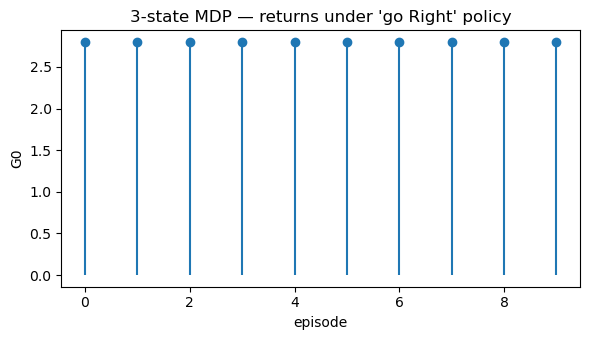

In [4]:
plt.figure(figsize=(6, 3.5))
plt.stem(range(len(returns)), returns, basefmt=" ")
plt.xlabel("episode")
plt.ylabel("G0")
plt.title("3-state MDP — returns under 'go Right' policy")
plt.tight_layout()
plt.show()

## 3. Policies and the Induced Markov Chain

A policy tells the agent how to choose actions.

- **Deterministic policy**: $ \pi(s) \in \mathcal{A} $.  
- **Stochastic policy**: $ \pi(a \mid s) = \Pr[A_t = a \mid S_t = s] $.

Given an MDP $ (\mathcal{S}, \mathcal{A}, P, R, \gamma) $ and a policy $ \pi $, we get:

- An induced Markov chain over states with transition matrix
  $$
  P^\pi(s' \mid s) = \sum_a \pi(a \mid s)\,P(s' \mid s, a),
  $$
- A policy-specific reward function $ r^\pi(s) = \mathbb{E}[R_{t+1} \mid S_t = s, \pi] $.

This is exactly the Markov reward process (MRP) viewpoint:
once the policy is fixed, RL evaluation becomes about analyzing this MRP.

We will use this idea heavily when deriving Bellman equations and dynamic programming methods next.

In [5]:
# Build tabular P^π and r^π for the small example under policy_right

num_states = 3
num_actions = 2

def build_P_pi_and_r_pi(policy):
    P_pi = np.zeros((num_states, num_states))
    r_pi = np.zeros(num_states)
    for s in range(num_states):
        for a in range(num_actions):
            pi_sa = 1.0 if policy[s] == a else 0.0  # deterministic policy
            for p, s_next, r in P[(s, a)]:
                P_pi[s, s_next] += pi_sa * p
                r_pi[s] += pi_sa * p * r
    return P_pi, r_pi

P_pi, r_pi = build_P_pi_and_r_pi(policy_right)

print("P^π (induced state transition under 'go Right'):")
print(P_pi)
print("\nr^π (expected immediate reward under 'go Right'):")
print(r_pi)

P^π (induced state transition under 'go Right'):
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]

r^π (expected immediate reward under 'go Right'):
[1. 2. 0.]


State distribution over time:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


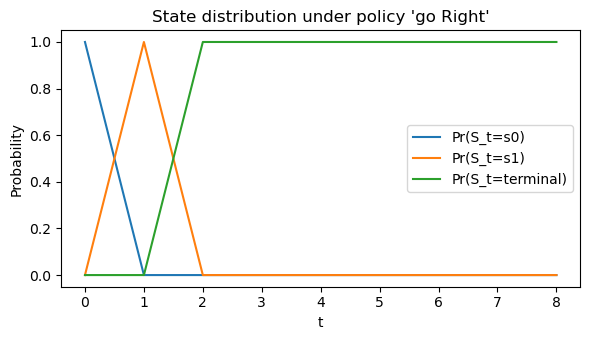

In [6]:
def roll_markov_chain(P_pi, T=10, s0=0):
    """Simulate state distribution evolution under P^π."""
    num_states = P_pi.shape[0]
    pi_t = np.zeros(num_states)
    pi_t[s0] = 1.0  # start distribution
    
    history = [pi_t.copy()]
    for _ in range(T):
        pi_t = pi_t @ P_pi
        history.append(pi_t.copy())
    return np.array(history)

dist_hist = roll_markov_chain(P_pi, T=8, s0=0)
print("State distribution over time:")
print(dist_hist)

plt.figure(figsize=(6,3.5))
for s in range(num_states):
    plt.plot(dist_hist[:, s], label=f"Pr(S_t={STATE_NAMES[s]})")
plt.xlabel("t")
plt.ylabel("Probability")
plt.title("State distribution under policy 'go Right'")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Value Functions — Preview for Bellman Equations

Once we fix a policy $ \pi $, we care about how good each state (or state–action pair) is.

- State-value function under policy $ \pi $:
  $$
  v^\pi(s) = \mathbb{E}_\pi \big[ G_t \mid S_t = s \big].
  $$
- Action-value function under policy $ \pi $:
  $$
  q^\pi(s,a) = \mathbb{E}_\pi \big[ G_t \mid S_t = s, A_t = a \big].
  $$

These functions will later satisfy Bellman expectation equations, linking $ v^\pi(s) $ to $ r^\pi(s) $ and $ P^\pi $.

For now, we’ll just approximate $ v^\pi $ by simulation to see the idea numerically.

In [7]:
def mc_estimate_v_pi(policy, gamma=0.9, num_episodes=500, max_steps=20):
    """
    Monte Carlo estimate of v^π by simulating episodes from each state.
    For this tiny example, we just start from each state and average returns.
    """
    v_hat = np.zeros(num_states)
    for s_start in range(num_states):
        returns = []
        for _ in range(num_episodes):
            # Run episode starting from s_start
            s = s_start
            G = 0.0
            discount = 1.0
            for t in range(max_steps):
                if s == 2:  # terminal
                    break
                a = policy[s]
                s_next, r = step(s, a)
                G += discount * r
                discount *= gamma
                s = s_next
            returns.append(G)
        v_hat[s_start] = np.mean(returns)
    return v_hat

v_mc = mc_estimate_v_pi(policy_right, gamma=gamma, num_episodes=1000)
print("MC estimate of v^π (go Right):", np.round(v_mc, 3))

MC estimate of v^π (go Right): [2.8 2.  0. ]


In [8]:
# For non-terminal states, we can solve v = r^π + γ P^π v
# Here we'll treat state 2 as terminal with v(terminal)=0 fixed.

# Build reduced system for s0,s1 only (state index 0 and 1)
S_nonterm = [0, 1]
P_sub = P_pi[np.ix_(S_nonterm, S_nonterm)]
r_sub = r_pi[S_nonterm]

I = np.eye(len(S_nonterm))
v_sub = np.linalg.solve(I - gamma * P_sub, r_sub)

v_closed = np.zeros(num_states)
v_closed[S_nonterm] = v_sub
v_closed[2] = 0.0

print("Closed-form v^π on non-terminals:", np.round(v_closed, 3))
print("MC estimate v^π:", np.round(v_mc, 3))

Closed-form v^π on non-terminals: [2.8 2.  0. ]
MC estimate v^π: [2.8 2.  0. ]


## Key Takeaways

- An MDP is defined by states, actions, transitions $P$, rewards $R$, and discount $\gamma$.  
- The Markov property lets us summarize the past through the current state.  
- A policy (deterministic or stochastic) induces a Markov chain with transition matrix $P^\pi$ and reward $r^\pi$.  
- Trajectories generate discounted returns $G_t$; RL agents aim to maximize $\mathbb{E}[G_0]$.  
- Value functions $v^\pi, q^\pi$ measure “goodness” of states and state–action pairs under a policy.

**Next:** `12_bellman_equations.ipynb` → Bellman expectation & optimality equations, and the foundations for dynamic programming.